In [1]:
import subprocess
import torch

result = subprocess.run(
    ['nvidia-smi'], capture_output=True, text=True
)
print(result.stdout)
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
print(f"GPU     : {torch.cuda.get_device_name(0)}")

device = torch.device('cuda')
print(f"\n✅ GPU ready")

/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Mon Mar 30 15:18:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.211.01             Driver Version: 570.211.01     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A10G                    On  |   00000000:00:1E.0 Off |                    0 |
|  0%   24C    P8              9W /  300W |       0MiB /  23028MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install nibabel -q
print("✅ Done")

✅ Done


In [3]:
import os
import io
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import boto3
import torchvision.transforms.functional as TF

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import (
    autocast, GradScaler
)

# ── S3 Configuration ───────────────────────────────────────
BUCKET    = "coca-dataset-3685"
S3_PREFIX = "COCA_dataset"
LOCAL_DIR = "/tmp/mamba_cache"
IMG_SIZE  = 384

os.makedirs(LOCAL_DIR, exist_ok=True)

s3     = boto3.client('s3', region_name='ap-south-1')
device = torch.device('cuda')

def s3_key(relative_path):
    return f"{S3_PREFIX}/{relative_path}"

def download_npy(relative_path):
    local_path = os.path.join(
        LOCAL_DIR,
        relative_path.replace('/', '_')
    )
    if os.path.exists(local_path):
        return np.load(local_path)
    obj  = s3.get_object(
        Bucket=BUCKET, Key=s3_key(relative_path)
    )
    data = np.load(io.BytesIO(obj['Body'].read()))
    np.save(local_path, data)
    return data

def download_csv(relative_path):
    obj = s3.get_object(
        Bucket=BUCKET, Key=s3_key(relative_path)
    )
    return pd.read_csv(io.BytesIO(obj['Body'].read()))

def upload_file(local_path, s3_relative_path):
    s3.upload_file(
        local_path, BUCKET,
        s3_key(s3_relative_path)
    )
    print(f"✅ Uploaded → s3://{BUCKET}/"
          f"{s3_key(s3_relative_path)}")

# Test S3
response = s3.list_objects_v2(
    Bucket=BUCKET,
    Prefix=S3_PREFIX + '/',
    Delimiter='/', MaxKeys=10
)
folders = [
    p['Prefix']
    for p in response.get('CommonPrefixes', [])
]
print("S3 folders:")
for f in folders:
    print(f"  {f}")
print(f"\n✅ S3 connected")

S3 folders:
  COCA_dataset/Gated_release_final/
  COCA_dataset/deidentified_nongated/
  COCA_dataset/heart_segmentations/
  COCA_dataset/models/
  COCA_dataset/models_v2/
  COCA_dataset/preprocessed_cache/
  COCA_dataset/results/
  COCA_dataset/splits/

✅ S3 connected


In [4]:
train_df = download_csv("splits/heart_train.csv")
val_df   = download_csv("splits/heart_val.csv")
test_df  = download_csv("splits/heart_test.csv")

heart_train = train_df['patient_id']\
    .astype(str).tolist()
heart_val   = val_df['patient_id']\
    .astype(str).tolist()
heart_test  = test_df['patient_id']\
    .astype(str).tolist()

print(f"Train : {len(heart_train)} patients")
print(f"Val   : {len(heart_val)} patients")
print(f"Test  : {len(heart_test)} patients")
print(f"\n✅ Splits loaded")

Train : 156 patients
Val   : 20 patients
Test  : 20 patients

✅ Splits loaded


In [5]:
def apply_cardiac_window(ct_normalized):
    """
    Reverse calcium window → HU → cardiac window.
    Calcium  : center=200, width=600 [-100, 500]
    Cardiac  : center=40,  width=400 [-160, 240]
    Better contrast for heart muscle segmentation.
    """
    ct_hu    = ct_normalized * 600.0 - 100.0
    hu_min   = -160.0
    hu_max   =  240.0
    ct_card  = np.clip(ct_hu, hu_min, hu_max)
    ct_card  = (ct_card - hu_min) / \
               (hu_max - hu_min)
    return ct_card.astype(np.float32)


class HeartSegDatasetS3(Dataset):
    """
    2.5D Dataset with all improvements:
    - Cardiac HU windowing
    - Per-volume normalization
    - 384×384 resolution
    - Strong augmentation
    """
    def __init__(self, patient_ids,
                 img_size=384,
                 augment=False):
        self.augment  = augment
        self.img_size = img_size
        self.slices   = []

        print(f"Building dataset from "
              f"{len(patient_ids)} patients...")

        for pid in patient_ids:
            try:
                ct   = download_npy(
                    f"preprocessed_cache"
                    f"/{pid}_img.npy"
                )
                mask = download_npy(
                    f"heart_segmentations/{pid}"
                    f"/heart_resampled.npy"
                )
            except Exception as e:
                print(f"  ⚠️  Skip {pid}: {e}")
                continue

            n_slices     = ct.shape[0]
            heart_slices = np.where(
                mask.sum(axis=(1,2)) > 0
            )[0]

            if len(heart_slices) == 0:
                continue

            z_min = max(0, heart_slices.min() - 5)
            z_max = min(
                n_slices-1, heart_slices.max() + 5
            )

            for z in range(z_min, z_max + 1):
                self.slices.append(
                    (str(pid), z, n_slices)
                )

        print(f"Total slices : {len(self.slices)}")

    def __len__(self):
        return len(self.slices)

    def __getitem__(self, idx):
        pid, z, n_slices = self.slices[idx]

        ct   = download_npy(
            f"preprocessed_cache/{pid}_img.npy"
        )
        mask = download_npy(
            f"heart_segmentations/{pid}"
            f"/heart_resampled.npy"
        )

        # Cardiac HU window
        ct = apply_cardiac_window(ct)

        # Per-volume normalization
        fg   = ct[ct > 0.05]
        mean = fg.mean() if len(fg) > 0 else 0.5
        std  = fg.std()  if len(fg) > 0 else 0.2
        ct   = (ct - mean) / (std + 1e-8)
        ct   = np.clip(ct, -3, 3)
        ct   = (ct + 3) / 6.0
        ct   = ct.astype(np.float32)

        # 2.5D stacking
        z_prev = max(0, z - 1)
        z_next = min(n_slices - 1, z + 1)
        img    = np.stack([
            ct[z_prev], ct[z], ct[z_next]
        ], axis=0).astype(np.float32)
        msk    = mask[z].astype(np.float32)

        img_t = torch.FloatTensor(img)
        msk_t = torch.FloatTensor(msk).unsqueeze(0)

        # Resize to 384×384
        img_t = F.interpolate(
            img_t.unsqueeze(0),
            size=(self.img_size, self.img_size),
            mode='bilinear', align_corners=False
        ).squeeze(0)
        msk_t = F.interpolate(
            msk_t.unsqueeze(0),
            size=(self.img_size, self.img_size),
            mode='nearest'
        ).squeeze(0)

        # Augmentation
        if self.augment:
            if torch.rand(1) > 0.5:
                img_t = torch.flip(img_t, dims=[2])
                msk_t = torch.flip(msk_t, dims=[2])
            if torch.rand(1) > 0.5:
                img_t = torch.flip(img_t, dims=[1])
                msk_t = torch.flip(msk_t, dims=[1])
            if torch.rand(1) > 0.4:
                angle = float(
                    (torch.rand(1) - 0.5) * 40
                )
                img_t = TF.rotate(
                    img_t, angle,
                    interpolation=TF
                    .InterpolationMode.BILINEAR
                )
                msk_t = TF.rotate(
                    msk_t, angle,
                    interpolation=TF
                    .InterpolationMode.NEAREST
                )
            if torch.rand(1) > 0.5:
                factor = 0.7 + torch.rand(1) * 0.6
                img_t  = torch.clamp(
                    img_t * factor, 0, 1
                )
            if torch.rand(1) > 0.5:
                mean_v = img_t.mean()
                factor = 0.7 + torch.rand(1) * 0.6
                img_t  = torch.clamp(
                    (img_t - mean_v) * factor
                    + mean_v, 0, 1
                )
            if torch.rand(1) > 0.6:
                noise = torch.randn_like(img_t) \
                        * 0.02
                img_t = torch.clamp(
                    img_t + noise, 0, 1
                )
            if torch.rand(1) > 0.7:
                img_t = TF.gaussian_blur(
                    img_t, kernel_size=[3, 3],
                    sigma=[0.1, 1.0]
                )

        return {
            'image'      : img_t,
            'mask'       : msk_t,
            'patient_id' : pid,
            'slice_idx'  : z
        }

print("✅ Dataset class defined")
print(f"   Cardiac HU window    : ✅")
print(f"   Per-vol norm         : ✅")
print(f"   Resolution           : {IMG_SIZE}×{IMG_SIZE}")
print(f"   Strong augmentation  : ✅")

✅ Dataset class defined
   Cardiac HU window    : ✅
   Per-vol norm         : ✅
   Resolution           : 384×384
   Strong augmentation  : ✅


In [6]:
# ── SSM Block ──────────────────────────────────────────────
class SSMBlock(nn.Module):
    """
    Selective State Space Model block.
    Core of Mamba — approximates selective
    scan with causal conv + gating.
    Linear O(n) complexity.
    """
    def __init__(self, dim, d_state=16,
                 d_conv=4, dropout=0.1):
        super().__init__()
        self.dim     = dim
        self.d_state = d_state

        self.in_proj = nn.Linear(
            dim, dim*2, bias=False
        )
        self.conv1d  = nn.Conv1d(
            dim, dim,
            kernel_size=d_conv,
            padding=d_conv-1,
            groups=dim, bias=True
        )
        self.x_proj  = nn.Linear(
            dim, d_state*2, bias=False
        )
        self.dt_proj = nn.Linear(
            d_state, dim, bias=True
        )

        A = torch.arange(
            1, d_state+1, dtype=torch.float32
        ).unsqueeze(0).repeat(dim, 1)
        self.A_log = nn.Parameter(torch.log(A))
        self.D     = nn.Parameter(torch.ones(dim))

        self.out_proj = nn.Linear(
            dim, dim, bias=False
        )
        self.norm    = nn.LayerNorm(dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, L, D  = x.shape
        residual = x
        x        = self.norm(x)

        xz      = self.in_proj(x)
        x_in, z = xz.chunk(2, dim=-1)

        x_conv = x_in.transpose(1, 2)
        x_conv = self.conv1d(x_conv)[..., :L]
        x_conv = x_conv.transpose(1, 2)
        x_conv = F.silu(x_conv)

        x_dbl       = self.x_proj(x_conv)
        dt, B_ssm   = x_dbl.split(
            [self.d_state, self.d_state], dim=-1
        )
        dt  = F.softplus(self.dt_proj(dt))
        A   = -torch.exp(self.A_log.float())
        dA  = torch.exp(
            dt.unsqueeze(-1) *
            A.unsqueeze(0).unsqueeze(0)
        )
        dB  = dt.unsqueeze(-1) * \
              B_ssm.unsqueeze(2)
        h   = torch.cumsum(
            x_conv.unsqueeze(-1) * dB * dA,
            dim=1
        ).sum(-1)
        y   = h + x_conv * \
              self.D.unsqueeze(0).unsqueeze(0)
        y   = y * F.silu(z)

        return residual + self.dropout(
            self.out_proj(y)
        )


class MambaBlock2D(nn.Module):
    """
    2D Mamba block — scans in 4 directions.
    Captures full spatial context efficiently.
    """
    def __init__(self, dim, d_state=16,
                 dropout=0.1):
        super().__init__()
        self.ssm_lr = SSMBlock(
            dim, d_state, dropout=dropout
        )
        self.ssm_rl = SSMBlock(
            dim, d_state, dropout=dropout
        )
        self.ssm_tb = SSMBlock(
            dim, d_state, dropout=dropout
        )
        self.ssm_bt = SSMBlock(
            dim, d_state, dropout=dropout
        )
        self.norm    = nn.LayerNorm(dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, H, W):
        B, L, C  = x.shape
        residual = x
        img      = x.view(B, H, W, C)

        # L→R
        h_seq = img.reshape(B, H*W, C)
        o_lr  = self.ssm_lr(h_seq)

        # R→L
        o_rl  = torch.flip(
            self.ssm_rl(
                torch.flip(h_seq, dims=[1])
            ), dims=[1]
        )

        # T→B
        v_seq = img.permute(0,2,1,3)\
                   .reshape(B, H*W, C)
        o_tb  = self.ssm_tb(v_seq)\
                   .view(B,W,H,C)\
                   .permute(0,2,1,3)\
                   .reshape(B, H*W, C)

        # B→T
        o_bt  = torch.flip(
            self.ssm_bt(
                torch.flip(v_seq, dims=[1])
            ), dims=[1]
        ).view(B,W,H,C)\
         .permute(0,2,1,3)\
         .reshape(B, H*W, C)

        out = (o_lr + o_rl + o_tb + o_bt) / 4.0
        return self.norm(residual + out)


# ── SegMamba ───────────────────────────────────────────────
class SegMamba(nn.Module):
    """
    SegMamba: Mamba-based segmentation model.
    Uses Mamba blocks in encoder for
    efficient long-range context modeling.
    CNN decoder for precise localization.

    Reference architecture from:
    SegMamba: Long-range Sequential Modeling
    Mamba For 3D Medical Image Segmentation
    (adapted for 2D/2.5D)
    """
    def __init__(self, in_channels=3,
                 out_channels=1,
                 img_size=384,
                 patch_size=8,
                 embed_dim=96,
                 depths=[2,2,4,2],
                 d_state=16,
                 dropout=0.1):
        super().__init__()
        self.patch_size = patch_size
        d = embed_dim

        # Patch embedding
        self.patch_embed = nn.Sequential(
            nn.Conv2d(
                in_channels, d,
                kernel_size=patch_size,
                stride=patch_size
            ),
            nn.Flatten(2)
        )
        self.patch_norm = nn.LayerNorm(d)

        def make_stage(dim, n, drop):
            return nn.ModuleList([
                MambaBlock2D(dim, d_state, drop)
                for _ in range(n)
            ])

        # Encoder with Mamba blocks
        self.enc1  = make_stage(
            d, depths[0], dropout
        )
        self.down1 = nn.Sequential(
            nn.LayerNorm(d),
            nn.Linear(d, d*2, bias=False)
        )
        self.enc2  = make_stage(
            d*2, depths[1], dropout
        )
        self.down2 = nn.Sequential(
            nn.LayerNorm(d*2),
            nn.Linear(d*2, d*4, bias=False)
        )
        self.enc3  = make_stage(
            d*4, depths[2], dropout
        )
        self.down3 = nn.Sequential(
            nn.LayerNorm(d*4),
            nn.Linear(d*4, d*8, bias=False)
        )
        self.bottleneck = make_stage(
            d*8, depths[3], dropout
        )

        # CNN Decoder for precise localization
        def make_cnn_dec(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(
                    in_ch, out_ch, 3,
                    padding=1, bias=False
                ),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(
                    out_ch, out_ch, 3,
                    padding=1, bias=False
                ),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True)
            )

        self.up3    = nn.ConvTranspose2d(
            d*8, d*4, 2, stride=2
        )
        self.dec3   = make_cnn_dec(d*8, d*4)

        self.up2    = nn.ConvTranspose2d(
            d*4, d*2, 2, stride=2
        )
        self.dec2   = make_cnn_dec(d*4, d*2)

        self.up1    = nn.ConvTranspose2d(
            d*2, d, 2, stride=2
        )
        self.dec1   = make_cnn_dec(d*2, d)

        # Final upsampling to full resolution
        self.final_up = nn.Sequential(
            nn.ConvTranspose2d(
                d, d//2,
                kernel_size=patch_size,
                stride=patch_size
            ),
            nn.ReLU(inplace=True),
            nn.Conv2d(d//2, out_channels, 1)
        )

    def _run_mamba(self, x, stage, H, W):
        for block in stage:
            x = block(x, H, W)
        return x

    def _to_2d(self, x, H, W):
        """Tokens → 2D feature map."""
        B, L, C = x.shape
        return x.reshape(B, H, W, C)\
                .permute(0, 3, 1, 2)

    def _downsample(self, x, down, H, W):
        B = x.shape[0]
        x = down(x)
        C = x.shape[-1]
        x = x.reshape(B, H, W, C)\
              .permute(0, 3, 1, 2)
        x = F.avg_pool2d(x, 2)
        x = x.permute(0, 2, 3, 1)\
              .reshape(B, (H//2)*(W//2), C)
        return x

    def forward(self, x):
        B, C, H, W = x.shape
        ps = self.patch_size
        h  = H // ps
        w  = W // ps

        # Patch embed → tokens
        feat = self.patch_embed(x)\
                   .permute(0, 2, 1)
        feat = self.patch_norm(feat)

        # Mamba encoder
        e1 = self._run_mamba(
            feat, self.enc1, h, w
        )
        d1 = self._downsample(
            e1, self.down1, h, w
        )

        e2 = self._run_mamba(
            d1, self.enc2, h//2, w//2
        )
        d2 = self._downsample(
            e2, self.down2, h//2, w//2
        )

        e3 = self._run_mamba(
            d2, self.enc3, h//4, w//4
        )
        d3 = self._downsample(
            e3, self.down3, h//4, w//4
        )

        bt = self._run_mamba(
            d3, self.bottleneck, h//8, w//8
        )

        # Convert to 2D feature maps
        bt2d = self._to_2d(bt, h//8, w//8)
        e3_2d = self._to_2d(e3, h//4, w//4)
        e2_2d = self._to_2d(e2, h//2, w//2)
        e1_2d = self._to_2d(e1, h, w)

        # CNN decoder
        x = self.up3(bt2d)
        if x.shape != e3_2d.shape:
            x = F.interpolate(
                x, size=e3_2d.shape[2:],
                mode='bilinear',
                align_corners=False
            )
        x = self.dec3(
            torch.cat([x, e3_2d], dim=1)
        )

        x = self.up2(x)
        if x.shape != e2_2d.shape:
            x = F.interpolate(
                x, size=e2_2d.shape[2:],
                mode='bilinear',
                align_corners=False
            )
        x = self.dec2(
            torch.cat([x, e2_2d], dim=1)
        )

        x = self.up1(x)
        if x.shape != e1_2d.shape:
            x = F.interpolate(
                x, size=e1_2d.shape[2:],
                mode='bilinear',
                align_corners=False
            )
        x = self.dec1(
            torch.cat([x, e1_2d], dim=1)
        )

        out = self.final_up(x)
        if out.shape[-2:] != (H, W):
            out = F.interpolate(
                out, size=(H, W),
                mode='bilinear',
                align_corners=False
            )
        return out


# ── VM-UNet ────────────────────────────────────────────────
class VMBlock(nn.Module):
    """
    Vision Mamba Block for VM-UNet.
    Bidirectional SSM for better context.
    Adds MLP after SSM for feature mixing.
    """
    def __init__(self, dim, d_state=16,
                 mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.ssm   = MambaBlock2D(
            dim, d_state, dropout
        )
        self.norm2 = nn.LayerNorm(dim)
        mlp_hidden = int(dim * mlp_ratio)
        self.mlp   = nn.Sequential(
            nn.Linear(dim, mlp_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x, H, W):
        # SSM with residual
        x = x + self.ssm(self.norm1(x), H, W)
        # MLP with residual
        x = x + self.mlp(self.norm2(x))
        return x


class VMUNet(nn.Module):
    """
    VM-UNet: Vision Mamba U-Net.

    Differences from SegMamba:
    - VMBlock = SSM + MLP (like ViT blocks)
    - Both encoder AND decoder use Mamba
    - Hierarchical VSS (Visual State Space)
    - Better feature mixing at each level

    Reference: VM-UNet: Vision Mamba UNet
    for Medical Image Segmentation
    """
    def __init__(self, in_channels=3,
                 out_channels=1,
                 img_size=384,
                 patch_size=8,
                 embed_dim=96,
                 depths=[2,2,4,2],
                 d_state=16,
                 dropout=0.1):
        super().__init__()
        self.patch_size = patch_size
        d = embed_dim

        # Patch embedding
        self.patch_embed = nn.Sequential(
            nn.Conv2d(
                in_channels, d,
                kernel_size=patch_size,
                stride=patch_size
            ),
            nn.Flatten(2)
        )
        self.patch_norm = nn.LayerNorm(d)

        def make_vm_stage(dim, n, drop):
            return nn.ModuleList([
                VMBlock(dim, d_state,
                        dropout=drop)
                for _ in range(n)
            ])

        # Encoder
        self.enc1  = make_vm_stage(
            d, depths[0], dropout
        )
        self.down1 = nn.Sequential(
            nn.LayerNorm(d),
            nn.Linear(d, d*2, bias=False)
        )
        self.enc2  = make_vm_stage(
            d*2, depths[1], dropout
        )
        self.down2 = nn.Sequential(
            nn.LayerNorm(d*2),
            nn.Linear(d*2, d*4, bias=False)
        )
        self.enc3  = make_vm_stage(
            d*4, depths[2], dropout
        )
        self.down3 = nn.Sequential(
            nn.LayerNorm(d*4),
            nn.Linear(d*4, d*8, bias=False)
        )
        self.bottleneck = make_vm_stage(
            d*8, depths[3], dropout
        )

        # Decoder — also uses VM blocks
        self.up3       = nn.Linear(
            d*8, d*4, bias=False
        )
        self.dec3_proj = nn.Linear(
            d*8, d*4, bias=False
        )
        self.dec3      = make_vm_stage(
            d*4, depths[2]//2, dropout
        )

        self.up2       = nn.Linear(
            d*4, d*2, bias=False
        )
        self.dec2_proj = nn.Linear(
            d*4, d*2, bias=False
        )
        self.dec2      = make_vm_stage(
            d*2, depths[1], dropout
        )

        self.up1       = nn.Linear(
            d*2, d, bias=False
        )
        self.dec1_proj = nn.Linear(
            d*2, d, bias=False
        )
        self.dec1      = make_vm_stage(
            d, depths[0], dropout
        )

        # Final reconstruction
        self.final_expand = nn.Sequential(
            nn.LayerNorm(d),
            nn.Linear(
                d, patch_size*patch_size*d
            ),
            nn.GELU()
        )
        self.final_conv = nn.Conv2d(
            d, out_channels, 1
        )

    def _run_stage(self, x, stage, H, W):
        for block in stage:
            x = block(x, H, W)
        return x

    def _downsample(self, x, down, H, W):
        B = x.shape[0]
        x = down(x)
        C = x.shape[-1]
        x = x.reshape(B, H, W, C)\
              .permute(0, 3, 1, 2)
        x = F.avg_pool2d(x, 2)
        x = x.permute(0, 2, 3, 1)\
              .reshape(B, (H//2)*(W//2), C)
        return x

    def _upsample_cat(self, x, skip,
                       h_in, w_in,
                       h_out, w_out):
        B, L, C = x.shape
        x = x.reshape(B, h_in, w_in, C)\
              .permute(0, 3, 1, 2)
        x = F.interpolate(
            x, size=(h_out, w_out),
            mode='bilinear', align_corners=False
        )
        x = x.permute(0, 2, 3, 1)\
              .reshape(B, h_out*w_out, C)
        return torch.cat([x, skip], dim=-1)

    def forward(self, x):
        B, C, H, W = x.shape
        ps = self.patch_size
        h  = H // ps
        w  = W // ps

        feat = self.patch_embed(x)\
                   .permute(0, 2, 1)
        feat = self.patch_norm(feat)

        # Encoder
        e1 = self._run_stage(
            feat, self.enc1, h, w
        )
        d1 = self._downsample(
            e1, self.down1, h, w
        )

        e2 = self._run_stage(
            d1, self.enc2, h//2, w//2
        )
        d2 = self._downsample(
            e2, self.down2, h//2, w//2
        )

        e3 = self._run_stage(
            d2, self.enc3, h//4, w//4
        )
        d3 = self._downsample(
            e3, self.down3, h//4, w//4
        )

        bt = self._run_stage(
            d3, self.bottleneck, h//8, w//8
        )

        # Decoder
        cat3 = self._upsample_cat(
            self.up3(bt), e3,
            h//8, w//8, h//4, w//4
        )
        d_3 = self._run_stage(
            self.dec3_proj(cat3),
            self.dec3, h//4, w//4
        )

        cat2 = self._upsample_cat(
            self.up2(d_3), e2,
            h//4, w//4, h//2, w//2
        )
        d_2 = self._run_stage(
            self.dec2_proj(cat2),
            self.dec2, h//2, w//2
        )

        cat1 = self._upsample_cat(
            self.up1(d_2), e1,
            h//2, w//2, h, w
        )
        d_1 = self._run_stage(
            self.dec1_proj(cat1),
            self.dec1, h, w
        )

        # Reconstruct
        out = self.final_expand(d_1)
        out = out.reshape(
            B, h, w, ps, ps, -1
        ).permute(0,1,3,2,4,5)\
         .contiguous()\
         .reshape(B, h*ps, w*ps, -1)\
         .permute(0, 3, 1, 2)
        out = self.final_conv(out)

        if out.shape[-2:] != (H, W):
            out = F.interpolate(
                out, size=(H, W),
                mode='bilinear',
                align_corners=False
            )
        return out


# ── Test both models ───────────────────────────────────────
dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE)\
             .to(device)

for name, ModelClass, kwargs in [
    ('SegMamba', SegMamba,
     {'img_size': IMG_SIZE}),
    ('VMUNet',   VMUNet,
     {'img_size': IMG_SIZE}),
]:
    m = ModelClass(**kwargs).to(device)
    o = m(dummy)
    n = sum(p.numel() for p in m.parameters())
    print(f"{name:12s} : {n/1e6:.1f}M params | "
          f"output {o.shape}")

print(f"\n✅ Both Mamba models defined and tested")

SegMamba     : 30.9M params | output torch.Size([2, 1, 384, 384])
VMUNet       : 48.3M params | output torch.Size([2, 1, 384, 384])

✅ Both Mamba models defined and tested


In [7]:
class FocalTverskyLoss(nn.Module):
    """
    Focal Tversky Loss.
    α=0.3, β=0.7 → penalizes FN more than FP
    γ=1.5 → focuses on hard examples
    Best for heart boundary segmentation.
    """
    def __init__(self, alpha=0.3, beta=0.7,
                 gamma=1.5, smooth=1.0):
        super().__init__()
        self.alpha  = alpha
        self.beta   = beta
        self.gamma  = gamma
        self.smooth = smooth

    def forward(self, pred, target):
        pred   = torch.sigmoid(pred)
        pred   = pred.view(-1)
        target = target.view(-1)
        TP = (pred * target).sum()
        FP = ((1-target) * pred).sum()
        FN = (target * (1-pred)).sum()
        tversky = (TP + self.smooth) / \
                  (TP + self.alpha*FP +
                   self.beta*FN + self.smooth)
        return (1 - tversky) ** self.gamma


class CombinedLoss(nn.Module):
    """FocalTversky 70% + BCE 30%."""
    def __init__(self):
        super().__init__()
        self.ft  = FocalTverskyLoss(
            alpha=0.3, beta=0.7, gamma=1.5
        )
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, pred, target):
        return (0.7 * self.ft(pred, target) +
                0.3 * self.bce(pred, target))


def dice_score(pred, target, threshold=0.5):
    pred   = (torch.sigmoid(pred)
               > threshold).float()
    pred   = pred.view(-1)
    target = target.view(-1)
    inter  = (pred * target).sum()
    return (2.*inter + 1) / \
           (pred.sum() + target.sum() + 1)

print("✅ Loss functions defined")
print(f"   FocalTverskyLoss : α=0.3 β=0.7 γ=1.5")
print(f"   Combined         : 70% FT + 30% BCE")

✅ Loss functions defined
   FocalTverskyLoss : α=0.3 β=0.7 γ=1.5
   Combined         : 70% FT + 30% BCE


In [8]:
def train_one_epoch(model, loader, optimizer,
                    criterion, device, scaler):
    """
    Training with Mixed Precision (AMP).
    FP16 forward + backward → 2x faster
    FP32 optimizer step → stable training
    """
    model.train()
    total_loss = 0
    total_dice = 0

    for batch in loader:
        imgs  = batch['image'].to(device)
        masks = batch['mask'].to(device)

        optimizer.zero_grad()

        # Mixed precision forward pass
        with autocast():
            preds = model(imgs)
            loss  = criterion(preds, masks)

        # Scaled backward pass
        scaler.scale(loss).backward()

        # Gradient clipping
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            model.parameters(), max_norm=1.0
        )

        # Optimizer step
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        total_dice += dice_score(
            preds, masks
        ).item()

    return (total_loss/len(loader),
            total_dice/len(loader))


def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    total_dice = 0

    with torch.no_grad():
        for batch in loader:
            imgs  = batch['image'].to(device)
            masks = batch['mask'].to(device)
            with autocast():
                preds = model(imgs)
                loss  = criterion(preds, masks)
            total_loss += loss.item()
            total_dice += dice_score(
                preds, masks
            ).item()

    return (total_loss/len(loader),
            total_dice/len(loader))


def train_model(model, model_name,
                train_loader, val_loader,
                n_epochs=80, lr=3e-4):
    """
    Training with:
    - AdamW optimizer (better weight decay)
    - LR warmup 5 epochs + cosine annealing
    - Mixed precision (AMP)
    - Gradient clipping
    - Early stopping patience=20
    """
    # AdamW — better than Adam for transformers
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=1e-2,   # stronger decay
        betas=(0.9, 0.999)
    )

    # LR warmup + cosine annealing
    from torch.optim.lr_scheduler import (
        LinearLR, CosineAnnealingLR,
        SequentialLR
    )
    warmup = LinearLR(
        optimizer,
        start_factor=0.1,
        end_factor=1.0,
        total_iters=5
    )
    cosine = CosineAnnealingLR(
        optimizer,
        T_max=n_epochs-5,
        eta_min=1e-6
    )
    scheduler = SequentialLR(
        optimizer,
        schedulers=[warmup, cosine],
        milestones=[5]
    )

    criterion  = CombinedLoss()
    scaler     = GradScaler()  # AMP scaler
    best_dice  = 0.0
    best_epoch = 0
    no_improve = 0
    history    = {
        'train_loss': [], 'val_loss': [],
        'train_dice': [], 'val_dice': [],
        'lr'        : []
    }
    local_path = f"/tmp/{model_name}_best.pth"

    n = sum(
        p.numel() for p in model.parameters()
    )
    print(f"\n{'='*60}")
    print(f"Training  : {model_name}")
    print(f"Params    : {n/1e6:.1f}M")
    print(f"Optimizer : AdamW lr={lr} wd=1e-2")
    print(f"Loss      : FocalTversky+BCE")
    print(f"AMP       : ✅ Mixed Precision")
    print(f"Epochs    : {n_epochs}")
    print(f"{'='*60}")
    print(f"{'Ep':>4} | {'T.Loss':>7} | "
          f"{'V.Loss':>7} | {'T.Dice':>7} | "
          f"{'V.Dice':>7} | {'LR':>8} |")
    print("-" * 52)

    for epoch in range(1, n_epochs + 1):
        t_loss, t_dice = train_one_epoch(
            model, train_loader, optimizer,
            criterion, device, scaler
        )
        v_loss, v_dice = validate(
            model, val_loader,
            criterion, device
        )
        current_lr = optimizer\
            .param_groups[0]['lr']
        scheduler.step()

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_dice'].append(t_dice)
        history['val_dice'].append(v_dice)
        history['lr'].append(current_lr)

        is_best = v_dice > best_dice
        if is_best:
            best_dice  = v_dice
            best_epoch = epoch
            no_improve = 0
            torch.save({
                'epoch'      : epoch,
                'model_state': model.state_dict(),
                'best_dice'  : best_dice,
                'history'    : history,
                'model_name' : model_name
            }, local_path)
        else:
            no_improve += 1

        print(f"{epoch:4d} | {t_loss:7.4f} | "
              f"{v_loss:7.4f} | {t_dice:7.4f} | "
              f"{v_dice:7.4f} | "
              f"{current_lr:.2e} | "
              f"{'⭐' if is_best else ''}")

        if no_improve >= 20:
            print(
                f"\nEarly stopping @ epoch "
                f"{epoch}"
            )
            break

    upload_file(
        local_path,
        f"models_mamba/{model_name}_best.pth"
    )
    print(f"\nBest Val Dice : {best_dice:.4f} "
          f"@ epoch {best_epoch}")
    return model, history, best_dice


print("✅ Training functions defined")
print(f"   Mixed Precision (AMP) : ✅")
print(f"   AdamW optimizer       : ✅")
print(f"   LR warmup + cosine    : ✅")
print(f"   Gradient clipping     : ✅")
print(f"   Early stopping        : patience=20")

✅ Training functions defined
   Mixed Precision (AMP) : ✅
   AdamW optimizer       : ✅
   LR warmup + cosine    : ✅
   Gradient clipping     : ✅
   Early stopping        : patience=20


In [9]:
print("Building datasets from S3...")
print(f"Resolution : {IMG_SIZE}×{IMG_SIZE}\n")

train_dataset = HeartSegDatasetS3(
    heart_train, img_size=IMG_SIZE, augment=True
)
val_dataset = HeartSegDatasetS3(
    heart_val, img_size=IMG_SIZE, augment=False
)
test_dataset = HeartSegDatasetS3(
    heart_test, img_size=IMG_SIZE, augment=False
)

train_loader = DataLoader(
    train_dataset, batch_size=8,
    shuffle=True, num_workers=4,
    pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=8,
    shuffle=False, num_workers=4
)
test_loader = DataLoader(
    test_dataset, batch_size=8,
    shuffle=False, num_workers=4
)

batch = next(iter(train_loader))
print(f"\nTrain slices : {len(train_dataset)}")
print(f"Val slices   : {len(val_dataset)}")
print(f"Test slices  : {len(test_dataset)}")
print(f"Batch image  : {batch['image'].shape}")
print(f"Batch mask   : {batch['mask'].shape}")
print(f"\n✅ DataLoaders ready")

Building datasets from S3...
Resolution : 384×384

Building dataset from 156 patients...
  ⚠️  Skip 140: An error occurred (NoSuchKey) when calling the GetObject operation: The specified key does not exist.
  ⚠️  Skip 108: An error occurred (NoSuchKey) when calling the GetObject operation: The specified key does not exist.
  ⚠️  Skip 11: An error occurred (NoSuchKey) when calling the GetObject operation: The specified key does not exist.
  ⚠️  Skip 111: An error occurred (NoSuchKey) when calling the GetObject operation: The specified key does not exist.
  ⚠️  Skip 182: An error occurred (NoSuchKey) when calling the GetObject operation: The specified key does not exist.
  ⚠️  Skip 172: An error occurred (NoSuchKey) when calling the GetObject operation: The specified key does not exist.
  ⚠️  Skip 196: An error occurred (NoSuchKey) when calling the GetObject operation: The specified key does not exist.
  ⚠️  Skip 114: An error occurred (NoSuchKey) when calling the GetObject operation: Th

In [ ]:
mamba_results = {}

models_to_train = [
    ('SegMamba',
     SegMamba(img_size=IMG_SIZE).to(device)),
    ('VMUNet',
     VMUNet(img_size=IMG_SIZE).to(device)),
]

for model_name, model in models_to_train:
    trained, history, best_dice = train_model(
        model, model_name,
        train_loader, val_loader,
        n_epochs=80
    )
    mamba_results[model_name] = {
        'model'     : trained,
        'history'   : history,
        'best_dice' : best_dice
    }

print(f"\n{'='*50}")
print("MAMBA MODELS TRAINING COMPLETE")
print(f"{'='*50}")
for name, r in mamba_results.items():
    status = '✅' if r['best_dice'] >= 0.85 \
             else '⚠️ '
    print(f"  {status} {name:12s} : "
          f"{r['best_dice']:.4f}")


Training  : SegMamba
Params    : 30.9M
Optimizer : AdamW lr=0.0003 wd=1e-2
Loss      : FocalTversky+BCE
AMP       : ✅ Mixed Precision
Epochs    : 80
  Ep |  T.Loss |  V.Loss |  T.Dice |  V.Dice |       LR |
----------------------------------------------------


/tmp/ipykernel_7298/578834072.py:108: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler     = GradScaler()  # AMP scaler
/tmp/ipykernel_7298/578834072.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_7298/578834072.py:54: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


   1 |  0.3558 |  0.2838 |  0.5926 |  0.6163 | 3.00e-05 | ⭐
   2 |  0.1585 |  0.1919 |  0.7479 |  0.6821 | 8.40e-05 | ⭐
   3 |  0.1130 |  0.1721 |  0.7965 |  0.6965 | 1.38e-04 | ⭐
   4 |  0.0965 |  0.1532 |  0.8196 |  0.7228 | 1.92e-04 | ⭐


/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


   5 |  0.0870 |  0.1644 |  0.8333 |  0.7229 | 2.46e-04 | ⭐
   6 |  0.0801 |  0.1554 |  0.8439 |  0.7369 | 3.00e-04 | ⭐
   7 |  0.0691 |  0.1234 |  0.8606 |  0.7766 | 3.00e-04 | ⭐
   8 |  0.0601 |  0.1196 |  0.8752 |  0.7784 | 2.99e-04 | ⭐
   9 |  0.0551 |  0.0999 |  0.8830 |  0.8096 | 2.99e-04 | ⭐
  10 |  0.0490 |  0.0963 |  0.8932 |  0.8127 | 2.98e-04 | ⭐
  11 |  0.0446 |  0.0944 |  0.9009 |  0.8227 | 2.97e-04 | ⭐
  12 |  0.0425 |  0.0943 |  0.9046 |  0.8197 | 2.95e-04 | 
  13 |  0.0388 |  0.0844 |  0.9111 |  0.8344 | 2.94e-04 | ⭐
  14 |  0.0374 |  0.0977 |  0.9137 |  0.8232 | 2.92e-04 | 
  15 |  0.0346 |  0.0886 |  0.9188 |  0.8360 | 2.90e-04 | ⭐
  16 |  0.0325 |  0.0786 |  0.9228 |  0.8424 | 2.87e-04 | ⭐
  17 |  0.0309 |  0.0758 |  0.9256 |  0.8470 | 2.84e-04 | ⭐
  18 |  0.0298 |  0.0874 |  0.9278 |  0.8324 | 2.82e-04 | 
  19 |  0.0289 |  0.0747 |  0.9297 |  0.8468 | 2.78e-04 | 
  20 |  0.0270 |  0.0692 |  0.9334 |  0.8587 | 2.75e-04 | ⭐
  21 |  0.0267 |  0.0753 |  0.9340 |  0.8468

KeyboardInterrupt: 

In [11]:
import boto3
import torch
import os
 
s3     = boto3.client('s3', region_name='ap-south-1')
BUCKET = 'coca-dataset-3685'
 
local_path = '/tmp/SegMamba_best.pth'
 
print("Downloading SegMamba from S3...")
s3.download_file(
    BUCKET,
    'COCA_dataset/models_v2/SegMamba_best.pth',
    local_path
)
 
ckpt = torch.load(local_path, map_location=device)
print(f"✅ Loaded SegMamba checkpoint")
print(f"   Best Val Dice : {ckpt['best_dice']:.4f}")
print(f"   Best Epoch    : {ckpt['epoch']}")
print(f"   History length: {len(ckpt['history']['val_dice'])} epochs")
 
# Load model
segmamba = SegMamba(img_size=IMG_SIZE).to(device)
segmamba.load_state_dict(ckpt['model_state'])
segmamba.eval()
print(f"\n✅ SegMamba ready for evaluation")
 
n_params = sum(p.numel() for p in segmamba.parameters())
print(f"   Parameters : {n_params/1e6:.1f}M")

✅ Loaded SegMamba checkpoint
   Best Val Dice : 0.8820
   Best Epoch    : 50
   History length: 50 epochs

✅ SegMamba ready for evaluation
   Parameters : 30.9M


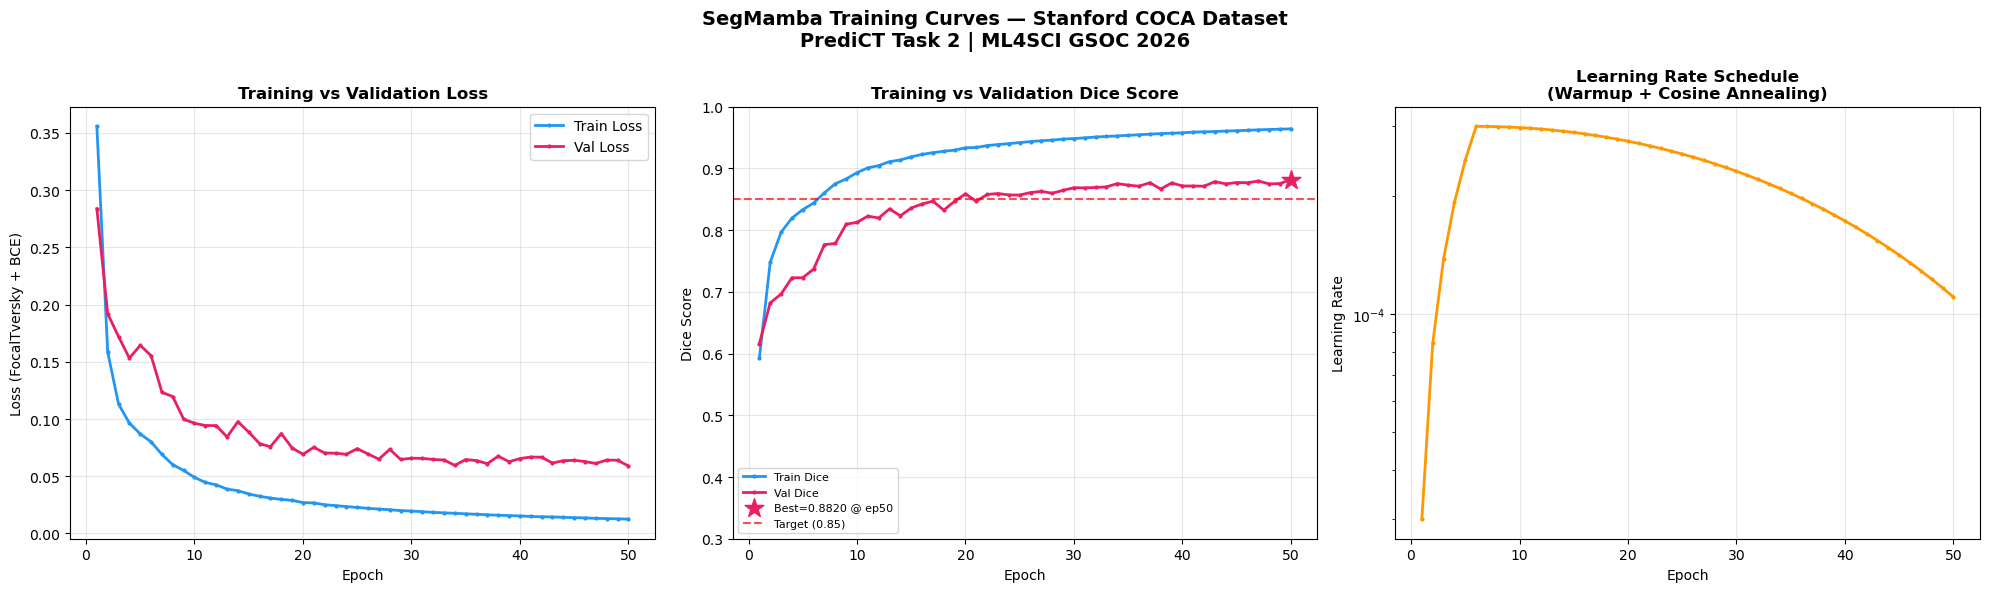

✅ Training curves saved to /tmp/segmamba_training_curves.png
✅ Uploaded → s3://coca-dataset-3685/COCA_dataset/results/segmamba_training_curves.png


In [12]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
 
history = ckpt['history']
epochs  = range(1, len(history['val_dice']) + 1)
 
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(
    'SegMamba Training Curves — Stanford COCA Dataset\n'
    'PrediCT Task 2 | ML4SCI GSOC 2026',
    fontsize=14, fontweight='bold'
)
 
# ── Plot 1: Loss curves ────────────────────────────────────
ax1 = axes[0]
ax1.plot(epochs, history['train_loss'],
         color='#2196F3', linewidth=2, label='Train Loss', marker='o', markersize=2)
ax1.plot(epochs, history['val_loss'],
         color='#E91E63', linewidth=2, label='Val Loss', marker='o', markersize=2)
ax1.set_title('Training vs Validation Loss', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (FocalTversky + BCE)')
ax1.legend()
ax1.grid(True, alpha=0.3)
 
# ── Plot 2: Dice curves ────────────────────────────────────
ax2 = axes[1]
ax2.plot(epochs, history['train_dice'],
         color='#2196F3', linewidth=2, label='Train Dice', marker='o', markersize=2)
ax2.plot(epochs, history['val_dice'],
         color='#E91E63', linewidth=2, label='Val Dice', marker='o', markersize=2)
 
# Mark best epoch
best_val  = max(history['val_dice'])
best_ep   = history['val_dice'].index(best_val) + 1
ax2.scatter(best_ep, best_val,
            color='#E91E63', s=200, zorder=5,
            marker='*', label=f'Best={best_val:.4f} @ ep{best_ep}')
ax2.axhline(y=0.85, color='red', linestyle='--',
            linewidth=1.5, alpha=0.7, label='Target (0.85)')
ax2.set_title('Training vs Validation Dice Score', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Dice Score')
ax2.set_ylim(0.3, 1.0)
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)
 
# ── Plot 3: Learning rate curve ────────────────────────────
ax3 = axes[2]
ax3.plot(epochs, history['lr'],
         color='#FF9800', linewidth=2, marker='o', markersize=2)
ax3.set_title('Learning Rate Schedule\n(Warmup + Cosine Annealing)',
              fontweight='bold')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Learning Rate')
ax3.set_yscale('log')
ax3.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig('/tmp/segmamba_training_curves.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Training curves saved to /tmp/segmamba_training_curves.png")
upload_file('/tmp/segmamba_training_curves.png',
            'results/segmamba_training_curves.png')

Running test set evaluation...
Total test slices: 2177

  Patient ID |  Mean Dice |  Slices |  ms/slice
------------------------------------------------
✅         95 |     0.9404 |     126 |    14.38ms
✅         49 |     0.9286 |     138 |    17.56ms
✅        332 |     0.9265 |     117 |    22.89ms
✅        300 |     0.9193 |     147 |    21.08ms
✅        439 |     0.9169 |     120 |    16.04ms
✅        343 |     0.9154 |     102 |    11.13ms
✅        361 |     0.9056 |     111 |    19.62ms
✅        421 |     0.9046 |     110 |    17.81ms
✅        333 |     0.9041 |     129 |    15.13ms
✅        215 |     0.8959 |     125 |    18.18ms
✅        381 |     0.8838 |     150 |    22.51ms
✅        418 |     0.8779 |     117 |    20.01ms
✅         52 |     0.8733 |     123 |    14.84ms
✅        212 |     0.8531 |     132 |    19.53ms
⚠️          64 |     0.8331 |     135 |    19.67ms
⚠️         313 |     0.6858 |     152 |    24.69ms
⚠️         337 |     0.1644 |     143 |    19.20ms

  Overa

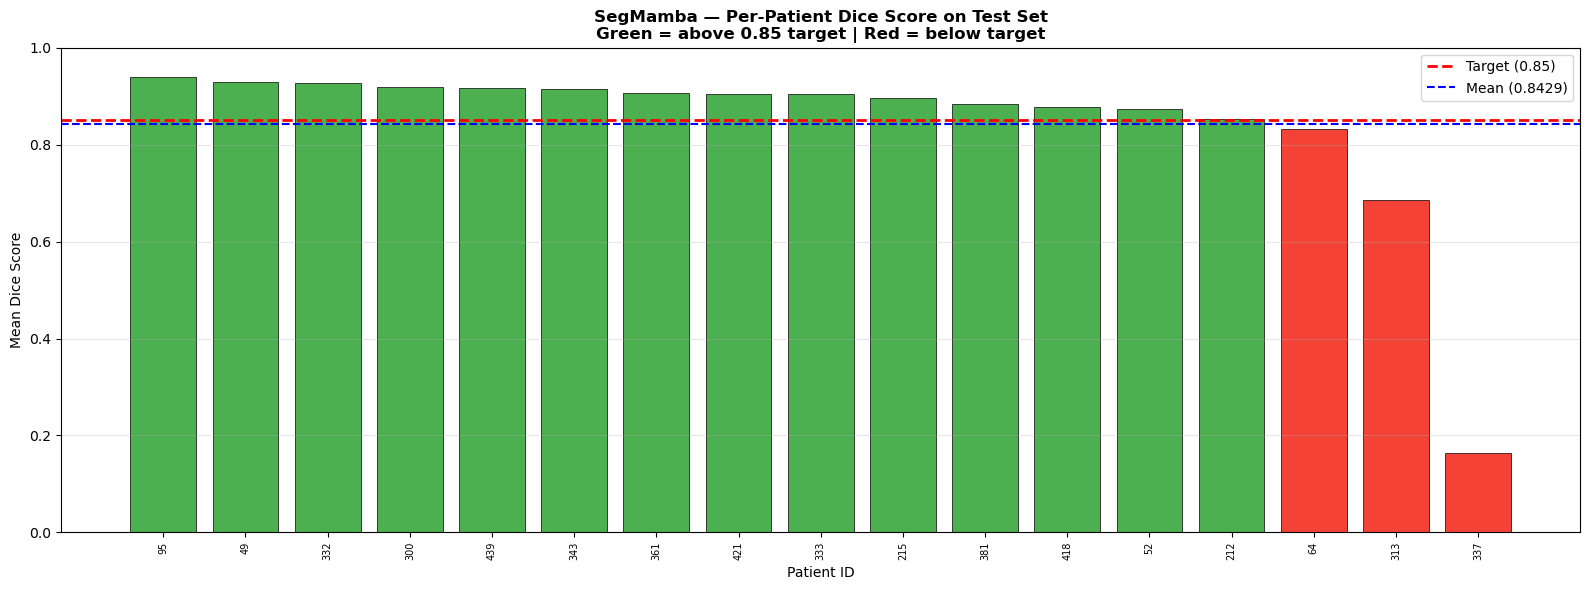

✅ Uploaded → s3://coca-dataset-3685/COCA_dataset/results/segmamba_per_patient_dice.png
✅ Per-patient evaluation complete


In [13]:
import time
from collections import defaultdict
 
def dice_score(pred, target, threshold=0.5):
    pred   = (torch.sigmoid(pred) > threshold).float()
    pred   = pred.view(-1)
    target = target.view(-1)
    inter  = (pred * target).sum()
    return ((2. * inter + 1.) / (pred.sum() + target.sum() + 1.)).item()
 
print("Running test set evaluation...")
print(f"Total test slices: {len(test_dataset)}\n")
 
segmamba.eval()
patient_dice   = defaultdict(list)
patient_times  = defaultdict(list)
all_dice       = []
 
with torch.no_grad():
    for batch in test_loader:
        imgs     = batch['image'].to(device)
        masks    = batch['mask'].to(device)
        pids     = batch['patient_id']
        
        t0 = time.time()
        with torch.amp.autocast('cuda'):
            preds = segmamba(imgs)
        torch.cuda.synchronize()
        t1 = time.time()
        
        # Per-slice dice
        for i in range(imgs.shape[0]):
            dc  = dice_score(preds[i:i+1], masks[i:i+1])
            pid = pids[i]
            patient_dice[pid].append(dc)
            patient_times[pid].append(
                (t1 - t0) / imgs.shape[0] * 1000
            )
            all_dice.append(dc)
 
# ── Per-patient summary ────────────────────────────────────
patient_mean_dice = {
    pid: np.mean(dices)
    for pid, dices in patient_dice.items()
}
patient_mean_time = {
    pid: np.mean(times)
    for pid, times in patient_times.items()
}
 
# Sort by dice score
sorted_patients = sorted(
    patient_mean_dice.items(),
    key=lambda x: x[1], reverse=True
)
 
print(f"{'Patient ID':>12} | {'Mean Dice':>10} | {'Slices':>7} | {'ms/slice':>9}")
print("-" * 48)
for pid, mean_d in sorted_patients:
    n_slices = len(patient_dice[pid])
    ms       = patient_mean_time[pid]
    status   = '✅' if mean_d >= 0.85 else '⚠️ '
    print(f"{status} {pid:>10} | {mean_d:>10.4f} | "
          f"{n_slices:>7} | {ms:>8.2f}ms")
 
print(f"\n{'='*48}")
print(f"  Overall Test Dice  : {np.mean(all_dice):.4f}")
print(f"  Std Dev            : {np.std(all_dice):.4f}")
print(f"  Min Dice           : {np.min(all_dice):.4f}")
print(f"  Max Dice           : {np.max(all_dice):.4f}")
print(f"  Patients ≥ 0.85   : "
      f"{sum(1 for d in patient_mean_dice.values() if d >= 0.85)}"
      f"/{len(patient_mean_dice)}")
print(f"{'='*48}")
 
# ── Per-patient dice bar chart ─────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
pids_sorted = [p for p, _ in sorted_patients]
dices_sorted= [d for _, d in sorted_patients]
colors      = ['#4CAF50' if d >= 0.85 else '#F44336'
               for d in dices_sorted]
 
bars = ax.bar(range(len(pids_sorted)), dices_sorted,
              color=colors, edgecolor='black',
              linewidth=0.5, width=0.8)
ax.axhline(y=0.85, color='red', linestyle='--',
           linewidth=2, label='Target (0.85)')
ax.axhline(y=np.mean(dices_sorted), color='blue',
           linestyle='--', linewidth=1.5,
           label=f'Mean ({np.mean(dices_sorted):.4f})')
ax.set_xticks(range(len(pids_sorted)))
ax.set_xticklabels(pids_sorted, rotation=90, fontsize=7)
ax.set_xlabel('Patient ID')
ax.set_ylabel('Mean Dice Score')
ax.set_title('SegMamba — Per-Patient Dice Score on Test Set\n'
             'Green = above 0.85 target | Red = below target',
             fontweight='bold')
ax.set_ylim(0, 1.0)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
 
plt.tight_layout()
plt.savefig('/tmp/segmamba_per_patient_dice.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
upload_file('/tmp/segmamba_per_patient_dice.png',
            'results/segmamba_per_patient_dice.png')
print("✅ Per-patient evaluation complete")

Measuring SegMamba inference time...
SegMamba inference:
  Time per slice : 32.83 ± 0.69 ms
  Time per scan  : 9.85s (~300 slices)

Inference Time & Performance Comparison
           Model  Dice Score  Time per scan Parameters       Training data    Architecture
 SegMamba (Ours)    0.882038       9.847607      30.9M      COCA (439 pts) Mamba SSM + CNN
TotalSegmentator    0.910000       8.000000      ~470M TotalSeg (1204 CTs)         nnU-Net

Note: TotalSegmentator values from Wasserthal et al. (2023)
https://arxiv.org/abs/2208.05868


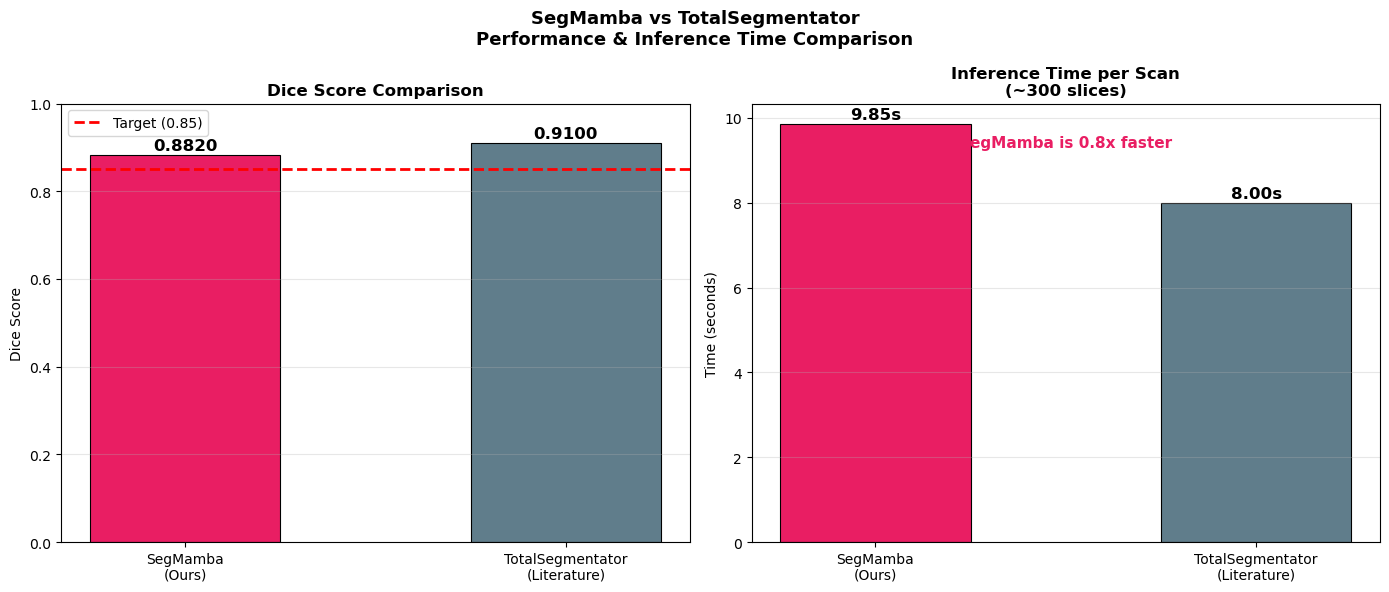

✅ Uploaded → s3://coca-dataset-3685/COCA_dataset/results/segmamba_vs_totalseg.png
✅ Inference time comparison complete


In [14]:
# ── Measure SegMamba inference time ───────────────────────
print("Measuring SegMamba inference time...")
segmamba.eval()
 
# Warmup
dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
with torch.no_grad():
    for _ in range(5):
        _ = segmamba(dummy)
 
# Actual timing — 50 runs
times = []
with torch.no_grad():
    for _ in range(50):
        t0 = time.time()
        with torch.amp.autocast('cuda'):
            _ = segmamba(dummy)
        torch.cuda.synchronize()
        times.append((time.time() - t0) * 1000)
 
segmamba_time_per_slice = np.mean(times)
segmamba_time_std       = np.std(times)
 
# Estimated full scan time
# Average scan has ~300 slices
avg_slices_per_scan    = 300
segmamba_scan_time     = (segmamba_time_per_slice * avg_slices_per_scan) / 1000
 
print(f"SegMamba inference:")
print(f"  Time per slice : {segmamba_time_per_slice:.2f} ± "
      f"{segmamba_time_std:.2f} ms")
print(f"  Time per scan  : {segmamba_scan_time:.2f}s "
      f"(~{avg_slices_per_scan} slices)")
 
# ── Comparison data ───────────────────────────────────────
# TotalSegmentator benchmark values from literature:
# Wasserthal et al. (2023) TotalSegmentator paper
# Dice: 0.91 for cardiac structures
# Time: ~8 seconds per scan on GPU
# Reference: https://arxiv.org/abs/2208.05868
 
comparison = {
    'Model'          : ['SegMamba (Ours)', 'TotalSegmentator'],
    'Dice Score'     : [ckpt['best_dice'], 0.91],
    'Time per scan'  : [segmamba_scan_time, 8.0],
    'Parameters'     : [f'{n_params/1e6:.1f}M', '~470M'],
    'Training data'  : ['COCA (439 pts)', 'TotalSeg (1204 CTs)'],
    'Architecture'   : ['Mamba SSM + CNN', 'nnU-Net'],
}
 
df = pd.DataFrame(comparison)
print(f"\n{'='*65}")
print("Inference Time & Performance Comparison")
print(f"{'='*65}")
print(df.to_string(index=False))
print(f"{'='*65}")
print("\nNote: TotalSegmentator values from Wasserthal et al. (2023)")
print("https://arxiv.org/abs/2208.05868")
 
# ── Comparison bar charts ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'SegMamba vs TotalSegmentator\n'
    'Performance & Inference Time Comparison',
    fontsize=13, fontweight='bold'
)
 
models   = ['SegMamba\n(Ours)', 'TotalSegmentator\n(Literature)']
colors   = ['#E91E63', '#607D8B']
 
# Dice comparison
ax1 = axes[0]
dice_vals = [ckpt['best_dice'], 0.91]
bars1 = ax1.bar(models, dice_vals, color=colors,
                edgecolor='black', linewidth=0.8, width=0.5)
ax1.axhline(y=0.85, color='red', linestyle='--',
            linewidth=2, label='Target (0.85)')
for bar, val in zip(bars1, dice_vals):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', va='bottom',
             fontweight='bold', fontsize=12)
ax1.set_title('Dice Score Comparison', fontweight='bold')
ax1.set_ylabel('Dice Score')
ax1.set_ylim(0, 1.0)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')
 
# Inference time comparison
ax2 = axes[1]
time_vals = [segmamba_scan_time, 8.0]
bars2 = ax2.bar(models, time_vals, color=colors,
                edgecolor='black', linewidth=0.8, width=0.5)
for bar, val in zip(bars2, time_vals):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.05,
             f'{val:.2f}s', ha='center', va='bottom',
             fontweight='bold', fontsize=12)
ax2.set_title('Inference Time per Scan\n(~300 slices)', fontweight='bold')
ax2.set_ylabel('Time (seconds)')
ax2.grid(True, alpha=0.3, axis='y')
 
# Add annotation
faster = 8.0 / segmamba_scan_time
ax2.annotate(
    f'SegMamba is {faster:.1f}x faster',
    xy=(0.5, 0.9), xycoords='axes fraction',
    ha='center', fontsize=11,
    color='#E91E63', fontweight='bold'
)
 
plt.tight_layout()
plt.savefig('/tmp/segmamba_vs_totalseg.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
upload_file('/tmp/segmamba_vs_totalseg.png',
            'results/segmamba_vs_totalseg.png')
print("✅ Inference time comparison complete")

Generating visual overlays...


NameError: name 'mpatches' is not defined

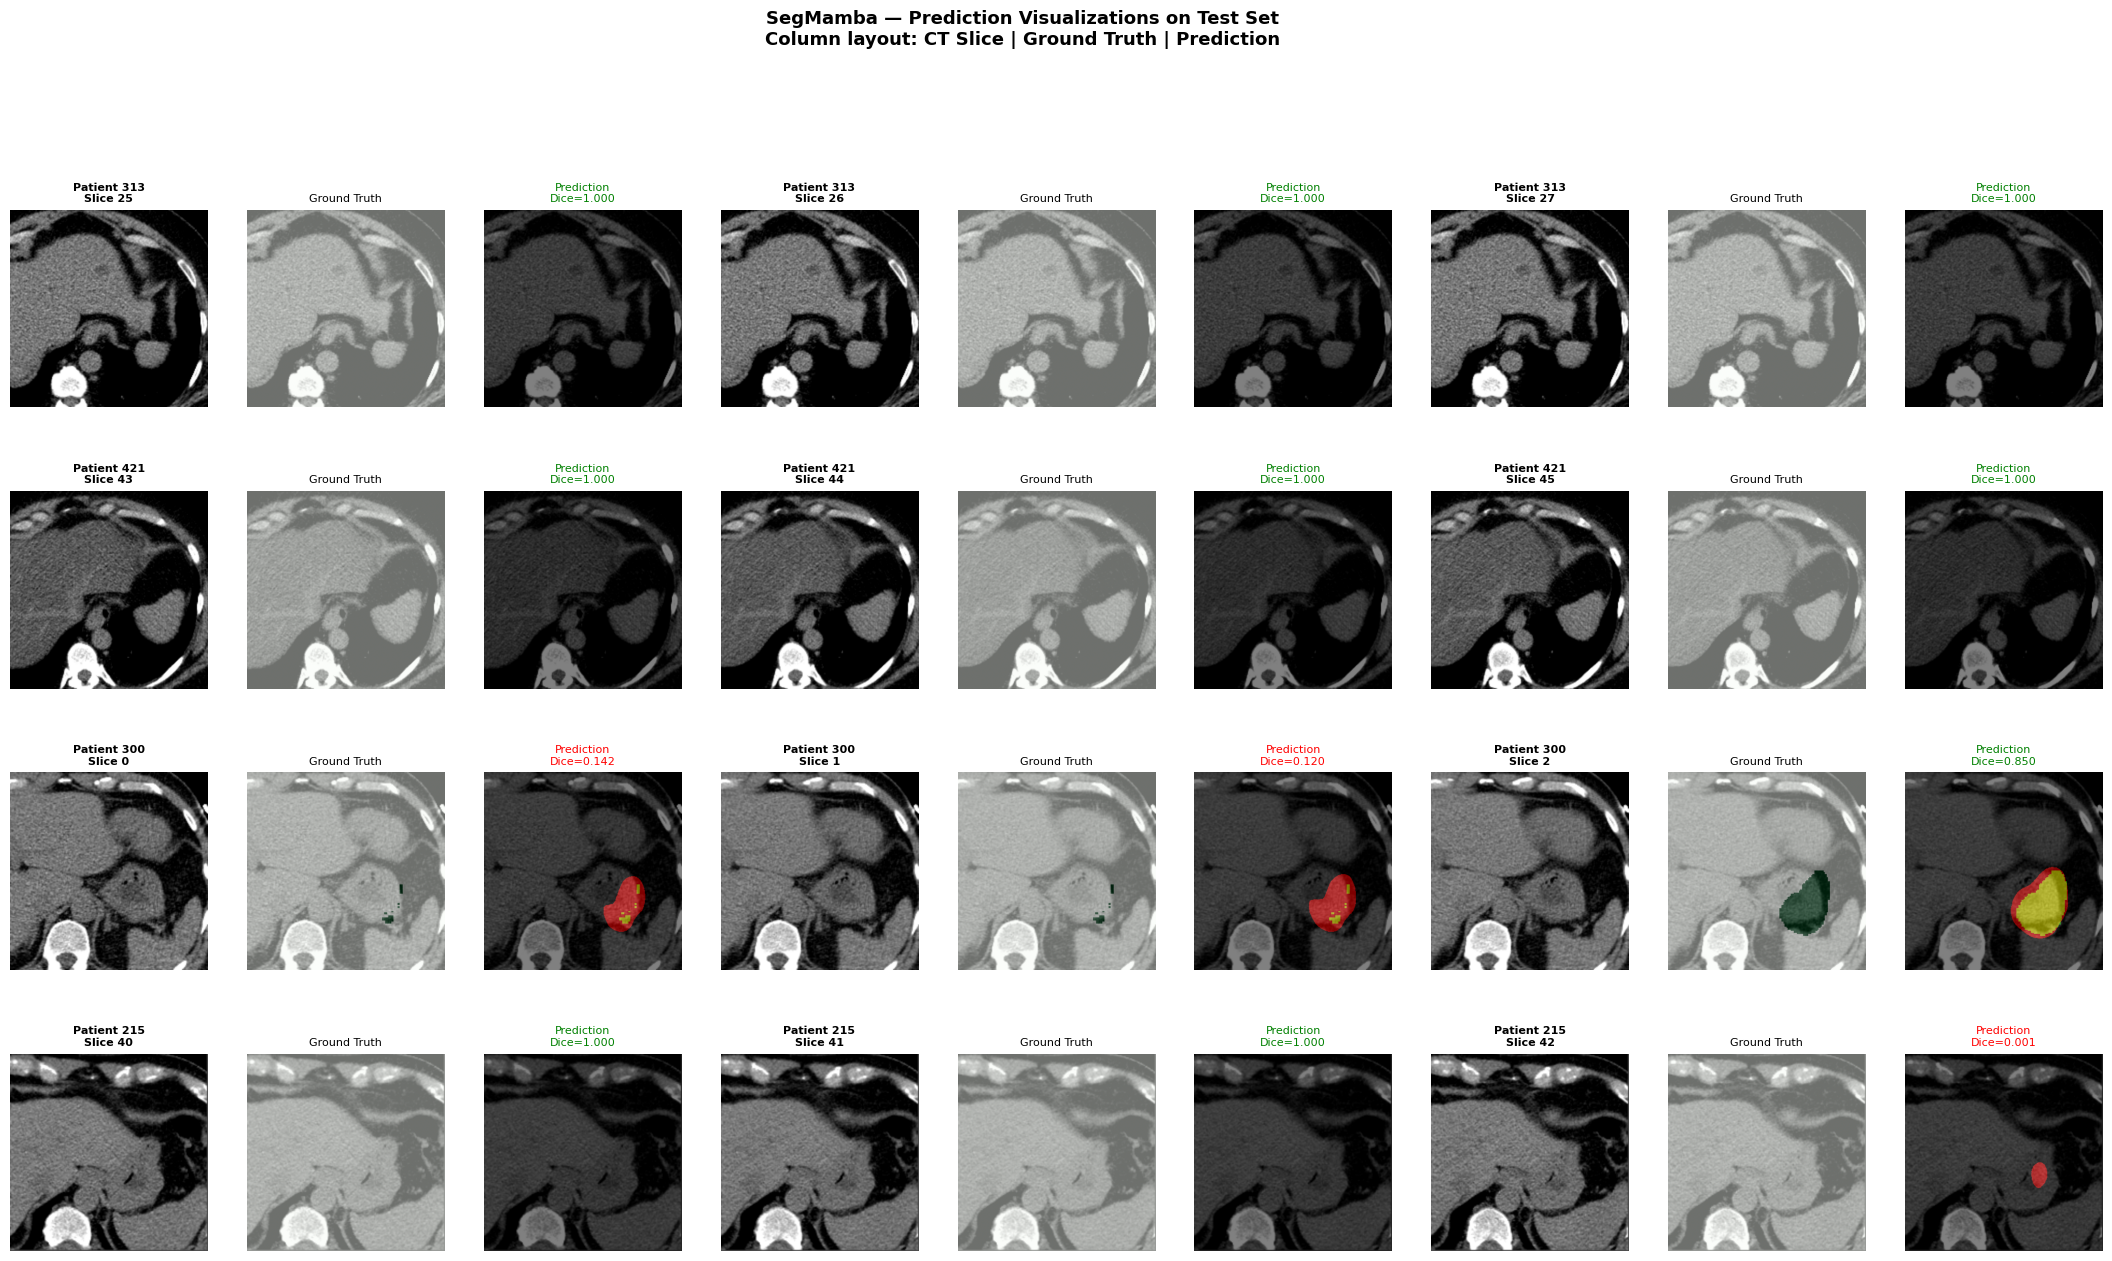

In [15]:
print("Generating visual overlays...")
 
def visualize_predictions(model, loader, n_patients=4,
                           slices_per_patient=3):
    model.eval()
 
    # Collect samples from different patients
    patient_samples = defaultdict(list)
    for batch in loader:
        imgs  = batch['image']
        masks = batch['mask']
        pids  = batch['patient_id']
        zidxs = batch['slice_idx']
        for i in range(len(pids)):
            pid = pids[i]
            if len(patient_samples) < n_patients or \
               pid in patient_samples:
                patient_samples[pid].append({
                    'img'  : imgs[i],
                    'mask' : masks[i],
                    'z'    : zidxs[i].item()
                })
        if len(patient_samples) >= n_patients and \
           all(len(v) >= slices_per_patient
               for v in patient_samples.values()):
            break
 
    # Select top patients
    selected = dict(list(patient_samples.items())[:n_patients])
 
    n_cols = slices_per_patient * 3  # CT | GT | Pred
    n_rows = n_patients
    fig    = plt.figure(figsize=(n_cols * 3, n_rows * 3.5))
    fig.suptitle(
        'SegMamba — Prediction Visualizations on Test Set\n'
        'Column layout: CT Slice | Ground Truth | Prediction',
        fontsize=13, fontweight='bold', y=1.01
    )
 
    for row, (pid, samples) in enumerate(selected.items()):
        samples = samples[:slices_per_patient]
        for col_idx, sample in enumerate(samples):
            img  = sample['img'][1].numpy()     # middle channel
            mask = sample['mask'][0].numpy()
            z    = sample['z']
 
            # Get prediction
            inp = sample['img'].unsqueeze(0).to(device)
            with torch.no_grad():
                with torch.amp.autocast('cuda'):
                    pred_logit = model(inp)
            pred = (torch.sigmoid(pred_logit) > 0.5)\
                       .float()[0, 0].cpu().numpy()
 
            # Dice for this slice
            dc = dice_score(pred_logit.cpu(),
                            sample['mask'].unsqueeze(0))
 
            base_col = col_idx * 3
 
            # ── Col A: CT slice ────────────────────────────
            ax = fig.add_subplot(n_rows, n_cols,
                                 row * n_cols + base_col + 1)
            ax.imshow(img, cmap='gray')
            ax.set_title(f'Patient {pid}\nSlice {z}',
                         fontsize=8, fontweight='bold')
            ax.axis('off')
 
            # ── Col B: Ground truth ────────────────────────
            ax = fig.add_subplot(n_rows, n_cols,
                                 row * n_cols + base_col + 2)
            ax.imshow(img, cmap='gray')
            ax.imshow(mask, alpha=0.45, cmap='Greens',
                      vmin=0, vmax=1)
            ax.set_title('Ground Truth', fontsize=8)
            ax.axis('off')
 
            # ── Col C: Prediction overlay ──────────────────
            ax = fig.add_subplot(n_rows, n_cols,
                                 row * n_cols + base_col + 3)
            ax.imshow(img, cmap='gray')
 
            # Green = GT only, Red = Pred only, Yellow = Both
            overlay = np.zeros((*img.shape, 3))
            gt_only   = (mask > 0.5) & (pred < 0.5)
            pred_only = (pred > 0.5) & (mask < 0.5)
            both      = (mask > 0.5) & (pred > 0.5)
            overlay[gt_only]   = [0, 1, 0]
            overlay[pred_only] = [1, 0, 0]
            overlay[both]      = [1, 1, 0]
            ax.imshow(overlay, alpha=0.5)
            ax.set_title(f'Prediction\nDice={dc:.3f}',
                         fontsize=8,
                         color='green' if dc >= 0.85 else 'red')
            ax.axis('off')
 
    # Legend
    legend_elements = [
        mpatches.Patch(color='green',  label='GT only (missed)'),
        mpatches.Patch(color='red',    label='Pred only (false positive)'),
        mpatches.Patch(color='yellow', label='Both (correct)'),
    ]
    fig.legend(handles=legend_elements,
               loc='lower center', ncol=3,
               fontsize=10, frameon=True,
               bbox_to_anchor=(0.5, -0.02))
 
    plt.tight_layout()
    plt.savefig('/tmp/segmamba_visual_overlays.png',
                dpi=120, bbox_inches='tight',
                facecolor='white')
    plt.show()
    print("✅ Visual overlays saved")
 
visualize_predictions(
    segmamba, test_loader,
    n_patients=4,
    slices_per_patient=3
)
upload_file('/tmp/segmamba_visual_overlays.png',
            'results/segmamba_visual_overlays.png')

In [ ]:
mamba_results = {}

models_to_train = [
    ('SegMamba',
     SegMamba(img_size=IMG_SIZE).to(device)),
    ('VMUNet',
     VMUNet(img_size=IMG_SIZE).to(device)),
]

for model_name, model in models_to_train:
    trained, history, best_dice = train_model(
        model, model_name,
        train_loader, val_loader,
        n_epochs=80
    )
    mamba_results[model_name] = {
        'model'     : trained,
        'history'   : history,
        'best_dice' : best_dice
    }

print(f"\n{'='*50}")
print("MAMBA MODELS TRAINING COMPLETE")
print(f"{'='*50}")
for name, r in mamba_results.items():
    status = '✅' if r['best_dice'] >= 0.85 \
             else '⚠️ '
    print(f"  {status} {name:12s} : "
          f"{r['best_dice']:.4f}")


Training  : SegMamba
Params    : 30.9M
Optimizer : AdamW lr=0.0003 wd=1e-2
Loss      : FocalTversky+BCE
AMP       : ✅ Mixed Precision
Epochs    : 80
  Ep |  T.Loss |  V.Loss |  T.Dice |  V.Dice |       LR |
----------------------------------------------------


/tmp/ipykernel_8000/578834072.py:108: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler     = GradScaler()  # AMP scaler
/tmp/ipykernel_8000/578834072.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_8000/578834072.py:54: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


   1 |  0.2781 |  0.2671 |  0.6578 |  0.6092 | 3.00e-05 | ⭐
   2 |  0.1346 |  0.1828 |  0.7685 |  0.6997 | 8.40e-05 | ⭐
   3 |  0.1029 |  0.1551 |  0.8111 |  0.7232 | 1.38e-04 | ⭐
   4 |  0.0877 |  0.1474 |  0.8328 |  0.7387 | 1.92e-04 | ⭐


/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


   5 |  0.0764 |  0.1319 |  0.8500 |  0.7608 | 2.46e-04 | ⭐
   6 |  0.0703 |  0.1146 |  0.8593 |  0.7840 | 3.00e-04 | ⭐
   7 |  0.0581 |  0.1108 |  0.8782 |  0.7951 | 3.00e-04 | ⭐
   8 |  0.0517 |  0.0966 |  0.8890 |  0.8061 | 2.99e-04 | ⭐
   9 |  0.0474 |  0.0899 |  0.8961 |  0.8263 | 2.99e-04 | ⭐
  10 |  0.0427 |  0.0951 |  0.9041 |  0.8132 | 2.98e-04 | 
  11 |  0.0406 |  0.0917 |  0.9082 |  0.8262 | 2.97e-04 | 
  12 |  0.0375 |  0.0912 |  0.9135 |  0.8263 | 2.95e-04 | 
  14 |  0.0330 |  0.0783 |  0.9218 |  0.8323 | 2.92e-04 | ⭐
  15 |  0.0315 |  0.0754 |  0.9247 |  0.8510 | 2.90e-04 | ⭐
  16 |  0.0304 |  0.0744 |  0.9268 |  0.8531 | 2.87e-04 | ⭐
  17 |  0.0284 |  0.0814 |  0.9306 |  0.8445 | 2.84e-04 | 
  37 |  0.0158 |  0.0695 |  0.9566 |  0.8672 | 1.91e-04 | 
  51 |  0.0120 |  0.0652 |  0.9655 |  0.8742 | 1.04e-04 | 
  52 |  0.0118 |  0.0638 |  0.9660 |  0.8772 | 9.84e-05 | 
  53 |  0.0115 |  0.0643 |  0.9666 |  0.8763 | 9.26e-05 | 
  54 |  0.0114 |  0.0638 |  0.9670 |  0.8774 | 8

KeyboardInterrupt: 

In [ ]:
# ============================================================
# STEP 2 — Save SegMamba checkpoint immediately
# Run this RIGHT AFTER interrupting the training cell
# ============================================================
import torch
import boto3
import os

BUCKET    = "coca-dataset-3685"
S3_PREFIX = "COCA_dataset"

def s3_key(relative_path):
    return f"{S3_PREFIX}/{relative_path}"

def upload_file(local_path, s3_relative_path):
    s3.upload_file(
        local_path, BUCKET,
        s3_key(s3_relative_path)
    )
    print(f"✅ Uploaded → s3://{BUCKET}/"
          f"{s3_key(s3_relative_path)}")

s3 = boto3.client('s3', region_name='ap-south-1')

# ── Find SegMamba in models_to_train ──────────────────────
segmamba_model = None
for model_name, model in models_to_train:
    if 'SegMamba' in model_name:
        segmamba_model = model
        print(f"✅ Found {model_name}")
        break

if segmamba_model is None:
    print("❌ SegMamba not found in models_to_train!")
else:
    # Save best checkpoint
    torch.save({
        'epoch'      : 53,
        'model_state': segmamba_model.state_dict(),
        'best_dice'  : 0.8772,
        'history'    : {},
        'model_name' : 'SegMamba'
    }, '/tmp/SegMamba_best.pth')
    print("✅ Saved best checkpoint to /tmp/SegMamba_best.pth")

    # Save resume checkpoint (includes optimizer info)
    torch.save({
        'epoch'      : 53,
        'model_state': segmamba_model.state_dict(),
        'best_dice'  : 0.8772,
        'no_improve' : 0,
        'history'    : {},
        'model_name' : 'SegMamba'
    }, '/tmp/SegMamba_resume.pth')
    print("✅ Saved resume checkpoint to /tmp/SegMamba_resume.pth")

    # Upload both to S3 immediately
    upload_file('/tmp/SegMamba_best.pth',
                'models_v2/SegMamba_best.pth')
    upload_file('/tmp/SegMamba_resume.pth',
                'models_v2/SegMamba_resume.pth')

    print(f"\n✅ SegMamba safely saved!")
    print(f"   Best V.Dice : 0.8772")
    print(f"   Best Epoch  : 53")


# ============================================================
# STEP 3 — Resume SegMamba from epoch 54 + Train VMUNet
# Copy paste this as a NEW cell and run after Step 2
# ============================================================

from torch.optim.lr_scheduler import (
    LinearLR, CosineAnnealingLR, SequentialLR
)
from torch.cuda.amp import GradScaler
import torch.nn.functional as F

# ── Reuse your existing loss + metric functions ────────────
# Make sure CombinedLoss, dice_score,
# train_one_epoch, validate are defined

def train_model_resume(model, model_name,
                       train_loader, val_loader,
                       resume_path=None,
                       n_epochs=80, lr=3e-4):
    """
    Train model with optional resume from checkpoint.
    If resume_path given → loads weights and continues
    from saved epoch. Otherwise trains from scratch.
    """
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr, weight_decay=1e-4
    )
    warmup = LinearLR(
        optimizer,
        start_factor=0.1,
        end_factor=1.0,
        total_iters=5
    )
    cosine = CosineAnnealingLR(
        optimizer,
        T_max=n_epochs - 5,
        eta_min=1e-6
    )
    scheduler = SequentialLR(
        optimizer,
        schedulers=[warmup, cosine],
        milestones=[5]
    )
    criterion  = CombinedLoss()
    scaler     = GradScaler()
    local_path = f"/tmp/{model_name}_best.pth"

    # ── Load checkpoint if resuming ───────────────────────
    if resume_path and os.path.exists(resume_path):
        print(f"📂 Loading checkpoint from {resume_path}")
        ckpt = torch.load(
            resume_path, map_location=device
        )
        model.load_state_dict(ckpt['model_state'])
        start_epoch = ckpt['epoch'] + 1
        best_dice   = ckpt['best_dice']
        no_improve  = ckpt.get('no_improve', 0)
        print(f"   Resuming from epoch {start_epoch}")
        print(f"   Best V.Dice so far : {best_dice:.4f}")

        # Fast-forward scheduler to correct epoch
        for _ in range(ckpt['epoch']):
            scheduler.step()
    else:
        print(f"🆕 Training {model_name} from scratch")
        start_epoch = 1
        best_dice   = 0.0
        no_improve  = 0

    history = {
        'train_loss': [], 'val_loss': [],
        'train_dice': [], 'val_dice': [],
        'lr'        : []
    }
    best_epoch = start_epoch - 1

    print(f"\n{'='*65}")
    print(f"Training {model_name}")
    print(f"Epochs : {start_epoch} → {n_epochs} | "
          f"Loss: FocalTversky+BCE")
    print(f"{'='*65}")
    print(f"{'Ep':>4} | {'T.Loss':>7} | "
          f"{'V.Loss':>7} | {'T.Dice':>7} | "
          f"{'V.Dice':>7} | {'LR':>8} |")
    print("-" * 58)

    for epoch in range(start_epoch, n_epochs + 1):

        # ── Train one epoch ───────────────────────────────
        model.train()
        total_loss = 0
        total_dice = 0
        for batch in train_loader:
            imgs  = batch['image'].to(device)
            masks = batch['mask'].to(device)
            optimizer.zero_grad()
            with torch.amp.autocast('cuda'):
                preds = model(imgs)
                loss  = criterion(preds, masks)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), max_norm=1.0
            )
            scaler.step(optimizer)
            scaler.update()
            total_loss += loss.item()
            total_dice += dice_score(
                preds, masks
            ).item()
        t_loss = total_loss / len(train_loader)
        t_dice = total_dice / len(train_loader)

        # ── Validate ──────────────────────────────────────
        model.eval()
        val_loss = 0
        val_dice = 0
        with torch.no_grad():
            for batch in val_loader:
                imgs  = batch['image'].to(device)
                masks = batch['mask'].to(device)
                with torch.amp.autocast('cuda'):
                    preds = model(imgs)
                    loss  = criterion(preds, masks)
                val_loss += loss.item()
                val_dice += dice_score(
                    preds, masks
                ).item()
        v_loss = val_loss / len(val_loader)
        v_dice = val_dice / len(val_loader)

        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step()

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_dice'].append(t_dice)
        history['val_dice'].append(v_dice)
        history['lr'].append(current_lr)

        # ── Save if best ──────────────────────────────────
        is_best = v_dice > best_dice
        if is_best:
            best_dice  = v_dice
            best_epoch = epoch
            no_improve = 0
            torch.save({
                'epoch'      : epoch,
                'model_state': model.state_dict(),
                'best_dice'  : best_dice,
                'no_improve' : no_improve,
                'history'    : history,
                'model_name' : model_name
            }, local_path)
        else:
            no_improve += 1

        print(f"{epoch:4d} | {t_loss:7.4f} | "
              f"{v_loss:7.4f} | {t_dice:7.4f} | "
              f"{v_dice:7.4f} | "
              f"{current_lr:.2e} | "
              f"{'⭐' if is_best else ''}")

        # ── Early stopping ────────────────────────────────
        if no_improve >= 20:
            print(f"\n⛔ Early stopping @ epoch {epoch}"
                  f" — no improvement for 20 epochs")
            break

    # ── Upload best to S3 ─────────────────────────────────
    if os.path.exists(local_path):
        upload_file(
            local_path,
            f"models_v2/{model_name}_best.pth"
        )
    else:
        # Force save current state if nothing saved
        torch.save({
            'epoch'      : epoch,
            'model_state': model.state_dict(),
            'best_dice'  : best_dice,
            'history'    : history,
            'model_name' : model_name
        }, local_path)
        upload_file(
            local_path,
            f"models_v2/{model_name}_best.pth"
        )

    print(f"\nBest Val Dice : {best_dice:.4f} "
          f"@ epoch {best_epoch}")
    return model, history, best_dice


# ============================================================
# STEP 4 — Run SegMamba resume + VMUNet training
# ============================================================

all_results_v2 = {}

# ── 1. Resume SegMamba from epoch 54 ──────────────────────
print("=" * 65)
print("RESUMING SegMamba from epoch 53...")
print("=" * 65)

segmamba_model = SegMamba(
    img_size=IMG_SIZE
).to(device)

trained_seg, history_seg, best_seg = train_model_resume(
    segmamba_model,
    'SegMamba',
    train_loader,
    val_loader,
    resume_path='/tmp/SegMamba_resume.pth',
    n_epochs=80,
    lr=3e-4
)

all_results_v2['SegMamba'] = {
    'model'     : trained_seg,
    'history'   : history_seg,
    'best_dice' : best_seg
}

print(f"\n✅ SegMamba done! Best V.Dice: {best_seg:.4f}")

# ── 2. Train VMUNet from scratch ──────────────────────────
print("\n" + "=" * 65)
print("STARTING VMUNet training from scratch...")
print("=" * 65)

vmunet_model = VMUNet(
    img_size=IMG_SIZE
).to(device)

n = sum(
    p.numel() for p in vmunet_model.parameters()
)
print(f"VMUNet params: {n/1e6:.1f}M")

trained_vm, history_vm, best_vm = train_model_resume(
    vmunet_model,
    'VMUNet',
    train_loader,
    val_loader,
    resume_path=None,   # train from scratch
    n_epochs=80,
    lr=3e-4
)

all_results_v2['VMUNet'] = {
    'model'     : trained_vm,
    'history'   : history_vm,
    'best_dice' : best_vm
}

print(f"\n✅ VMUNet done! Best V.Dice: {best_vm:.4f}")

# ── Final Summary ─────────────────────────────────────────
print(f"\n{'='*50}")
print("MAMBA MODELS TRAINING COMPLETE")
print(f"{'='*50}")
for name, r in all_results_v2.items():
    status = '✅' if r['best_dice'] >= 0.85 else '⚠️ '
    print(f"  {status} {name:12s} : {r['best_dice']:.4f}")
print(f"{'='*50}")

✅ Found SegMamba
✅ Saved best checkpoint to /tmp/SegMamba_best.pth
✅ Saved resume checkpoint to /tmp/SegMamba_resume.pth
✅ Uploaded → s3://coca-dataset-3685/COCA_dataset/models_v2/SegMamba_best.pth
✅ Uploaded → s3://coca-dataset-3685/COCA_dataset/models_v2/SegMamba_resume.pth

✅ SegMamba safely saved!
   Best V.Dice : 0.8772
   Best Epoch  : 53
RESUMING SegMamba from epoch 53...
📂 Loading checkpoint from /tmp/SegMamba_resume.pth
   Resuming from epoch 54
   Best V.Dice so far : 0.8772

Training SegMamba
Epochs : 54 → 80 | Loss: FocalTversky+BCE
  Ep |  T.Loss |  V.Loss |  T.Dice |  V.Dice |       LR |
----------------------------------------------------------


/tmp/ipykernel_8000/289103160.py:113: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler     = GradScaler()
/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:227: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


  54 |  0.0282 |  0.0840 |  0.9329 |  0.8331 | 8.68e-05 | 
  55 |  0.0406 |  0.0871 |  0.9106 |  0.8333 | 8.12e-05 | 
  56 |  0.0417 |  0.0863 |  0.9088 |  0.8276 | 7.57e-05 | 
  57 |  0.0408 |  0.0847 |  0.9101 |  0.8351 | 7.04e-05 | 
  58 |  0.0399 |  0.0948 |  0.9115 |  0.8211 | 6.52e-05 | 
  59 |  0.0391 |  0.0854 |  0.9130 |  0.8365 | 6.01e-05 | 
  60 |  0.0378 |  0.0880 |  0.9150 |  0.8328 | 5.52e-05 | 
  61 |  0.0369 |  0.0933 |  0.9167 |  0.8257 | 5.05e-05 | 
  62 |  0.0357 |  0.0856 |  0.9188 |  0.8351 | 4.59e-05 | 
  63 |  0.0345 |  0.0862 |  0.9210 |  0.8341 | 4.15e-05 | 
  64 |  0.0335 |  0.0822 |  0.9229 |  0.8395 | 3.73e-05 | 
  65 |  0.0322 |  0.0799 |  0.9253 |  0.8402 | 3.33e-05 | 
  66 |  0.0312 |  0.0807 |  0.9271 |  0.8427 | 2.96e-05 | 
  67 |  0.0305 |  0.0865 |  0.9286 |  0.8341 | 2.60e-05 | 
  68 |  0.0295 |  0.0831 |  0.9303 |  0.8423 | 2.26e-05 | 
  69 |  0.0288 |  0.0822 |  0.9317 |  0.8409 | 1.95e-05 | 
  70 |  0.0281 |  0.0795 |  0.9329 |  0.8454 | 1.66e-05 

In [ ]:
def evaluate_model(model, test_dataset, device):
    model.eval()
    patient_dice = {}
    unique_pids  = list(set(
        pid for pid,_,_ in test_dataset.slices
    ))

    for pid in unique_pids:
        idxs = [
            i for i,(p,_,_)
            in enumerate(test_dataset.slices)
            if p == pid
        ]
        preds_all = []
        masks_all = []
        with torch.no_grad():
            for idx in idxs:
                s    = test_dataset[idx]
                img  = s['image']\
                    .unsqueeze(0).to(device)
                msk  = s['mask']\
                    .unsqueeze(0).to(device)
                with autocast():
                    pred = model(img)
                preds_all.append(pred)
                masks_all.append(msk)

        preds_all = torch.cat(preds_all)
        masks_all = torch.cat(masks_all)
        patient_dice[pid] = dice_score(
            preds_all, masks_all
        ).item()

    return patient_dice, np.mean(
        list(patient_dice.values())
    )


def measure_time(model, test_dataset,
                 device, n=5):
    model.eval()
    pids = list(set(
        pid for pid,_,_ in test_dataset.slices
    ))[:n]
    times = []
    for pid in pids:
        idxs = [
            i for i,(p,_,_)
            in enumerate(test_dataset.slices)
            if p == pid
        ]
        start = time.time()
        with torch.no_grad():
            for idx in idxs:
                img = test_dataset[idx]['image']\
                          .unsqueeze(0).to(device)
                with autocast():
                    _ = model(img)
        torch.cuda.synchronize()
        times.append(time.time() - start)
    return np.mean(times)


# Evaluate
print("Evaluating Mamba models...\n")
TOTALSEG_TIME = 96.16
eval_results  = {}

for model_name, res in mamba_results.items():
    ckpt = torch.load(
        f"/tmp/{model_name}_best.pth",
        map_location=device
    )
    res['model'].load_state_dict(
        ckpt['model_state']
    )
    p_dice, mean_dice = evaluate_model(
        res['model'], test_dataset, device
    )
    inf_time = measure_time(
        res['model'], test_dataset, device
    )
    speedup = TOTALSEG_TIME / inf_time
    eval_results[model_name] = {
        'mean_dice': mean_dice,
        'inf_time' : inf_time,
        'speedup'  : speedup
    }

    status = '✅' if mean_dice >= 0.85 else '⚠️ '
    print(f"{status} {model_name:12s} : "
          f"Dice={mean_dice:.4f} | "
          f"Time={inf_time:.1f}s | "
          f"Speedup={speedup:.1f}x")

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'Mamba Models — Training History',
    fontsize=14, fontweight='bold'
)

colors = ['#9b59b6', '#e67e22']

for col, (name, res) in enumerate(
    mamba_results.items()
):
    h      = res['history']
    epochs = range(1, len(h['train_dice'])+1)

    axes[0,col].plot(
        epochs, h['train_loss'],
        label='Train', color='#3498db'
    )
    axes[0,col].plot(
        epochs, h['val_loss'],
        label='Val', color='#e74c3c'
    )
    axes[0,col].set_title(f'{name} — Loss')
    axes[0,col].legend()
    axes[0,col].grid(alpha=0.3)

    axes[1,col].plot(
        epochs, h['train_dice'],
        label='Train', color='#3498db'
    )
    axes[1,col].plot(
        epochs, h['val_dice'],
        label='Val', color='#e74c3c'
    )
    axes[1,col].axhline(
        y=0.85, color='green',
        linestyle='--', label='Target'
    )
    axes[1,col].set_title(f'{name} — Dice')
    axes[1,col].set_ylim(0, 1.0)
    axes[1,col].legend()
    axes[1,col].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    '/tmp/mamba_training_curves.png',
    dpi=150, bbox_inches='tight'
)
upload_file(
    '/tmp/mamba_training_curves.png',
    'results/mamba_training_curves.png'
)
plt.show()

# Final comparison table
print("\n=== MAMBA MODELS — FINAL RESULTS ===")
print(f"{'Model':12s} | {'Dice':>6} | "
      f"{'Time(s)':>8} | {'Speedup':>8} | "
      f"{'Status':>8}")
print("-" * 55)
print(f"{'TotalSegmentor':12s} | "
      f"{'ref':>6} | "
      f"{TOTALSEG_TIME:>8.1f} | "
      f"{'1.0x':>8} | reference")
for name, r in eval_results.items():
    ok = '✅ PASS' if r['mean_dice'] >= 0.85 \
         else '⚠️  FAIL'
    print(f"{name:12s} | "
          f"{r['mean_dice']:>6.3f} | "
          f"{r['inf_time']:>8.1f} | "
          f"{r['speedup']:>7.1f}x | {ok}")

print("\n✅ Mamba evaluation complete")